<a href="https://colab.research.google.com/github/OneStack-x/Heart-Disease-Prediction-using-Random-Forest/blob/main/heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import kagglehub
import pandas as pd
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


In [29]:
print(path)

/kaggle/input/heart-failure-prediction


In [30]:
import os
os.listdir(path)

['heart.csv']

In [31]:
csv_path = os.path.join(path, "heart.csv")
df = pd.read_csv(csv_path)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [32]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [33]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [34]:
df.shape

(918, 12)

In [35]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [36]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [39]:
df.columns
df["HeartDisease"].unique()

array([0, 1])

In [40]:
df["HeartDisease"].value_counts()

,count
HeartDisease,
1,508
0,410


**we need to check whether the classes are balanced.**

In [41]:
(df["HeartDisease"].value_counts(normalize=True) * 100).round(2)

,proportion
HeartDisease,
1,55.34
0,44.66


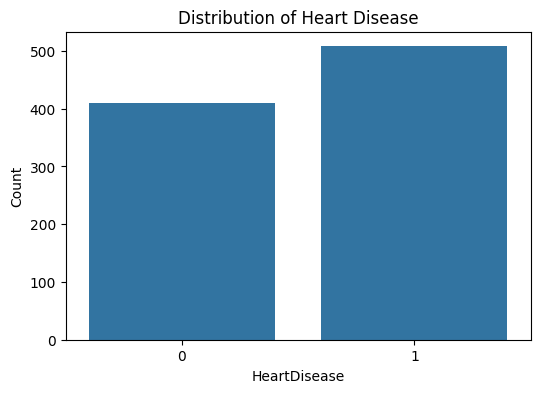

In [42]:
plt.figure(figsize=(6,4))

sns.countplot(x="HeartDisease", data=df)

plt.title("Distribution of Heart Disease")
plt.xlabel("HeartDisease")
plt.ylabel("Count")

plt.show()

# **Correlation Matrix**

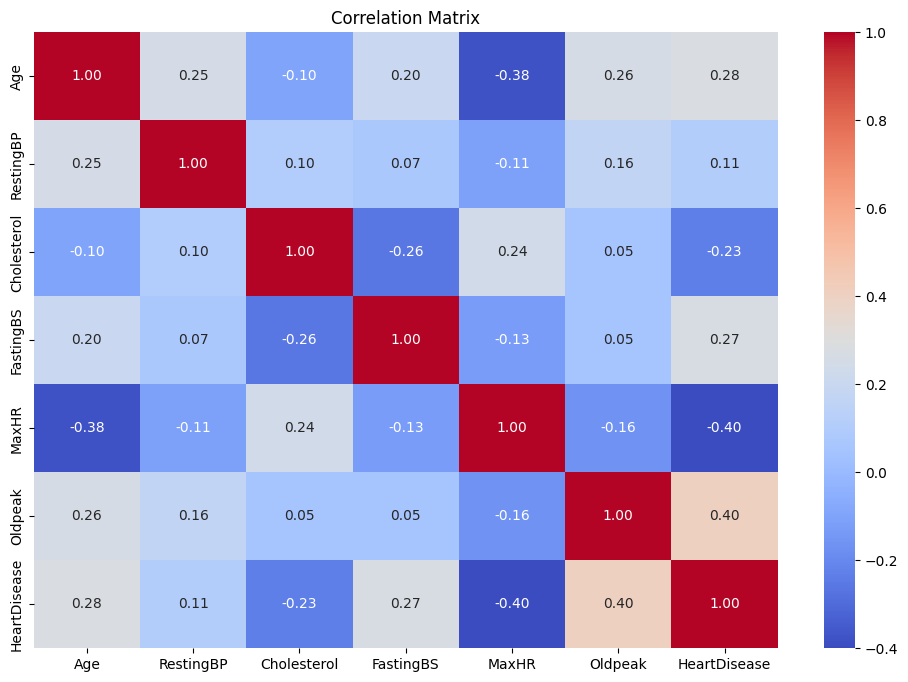

In [43]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

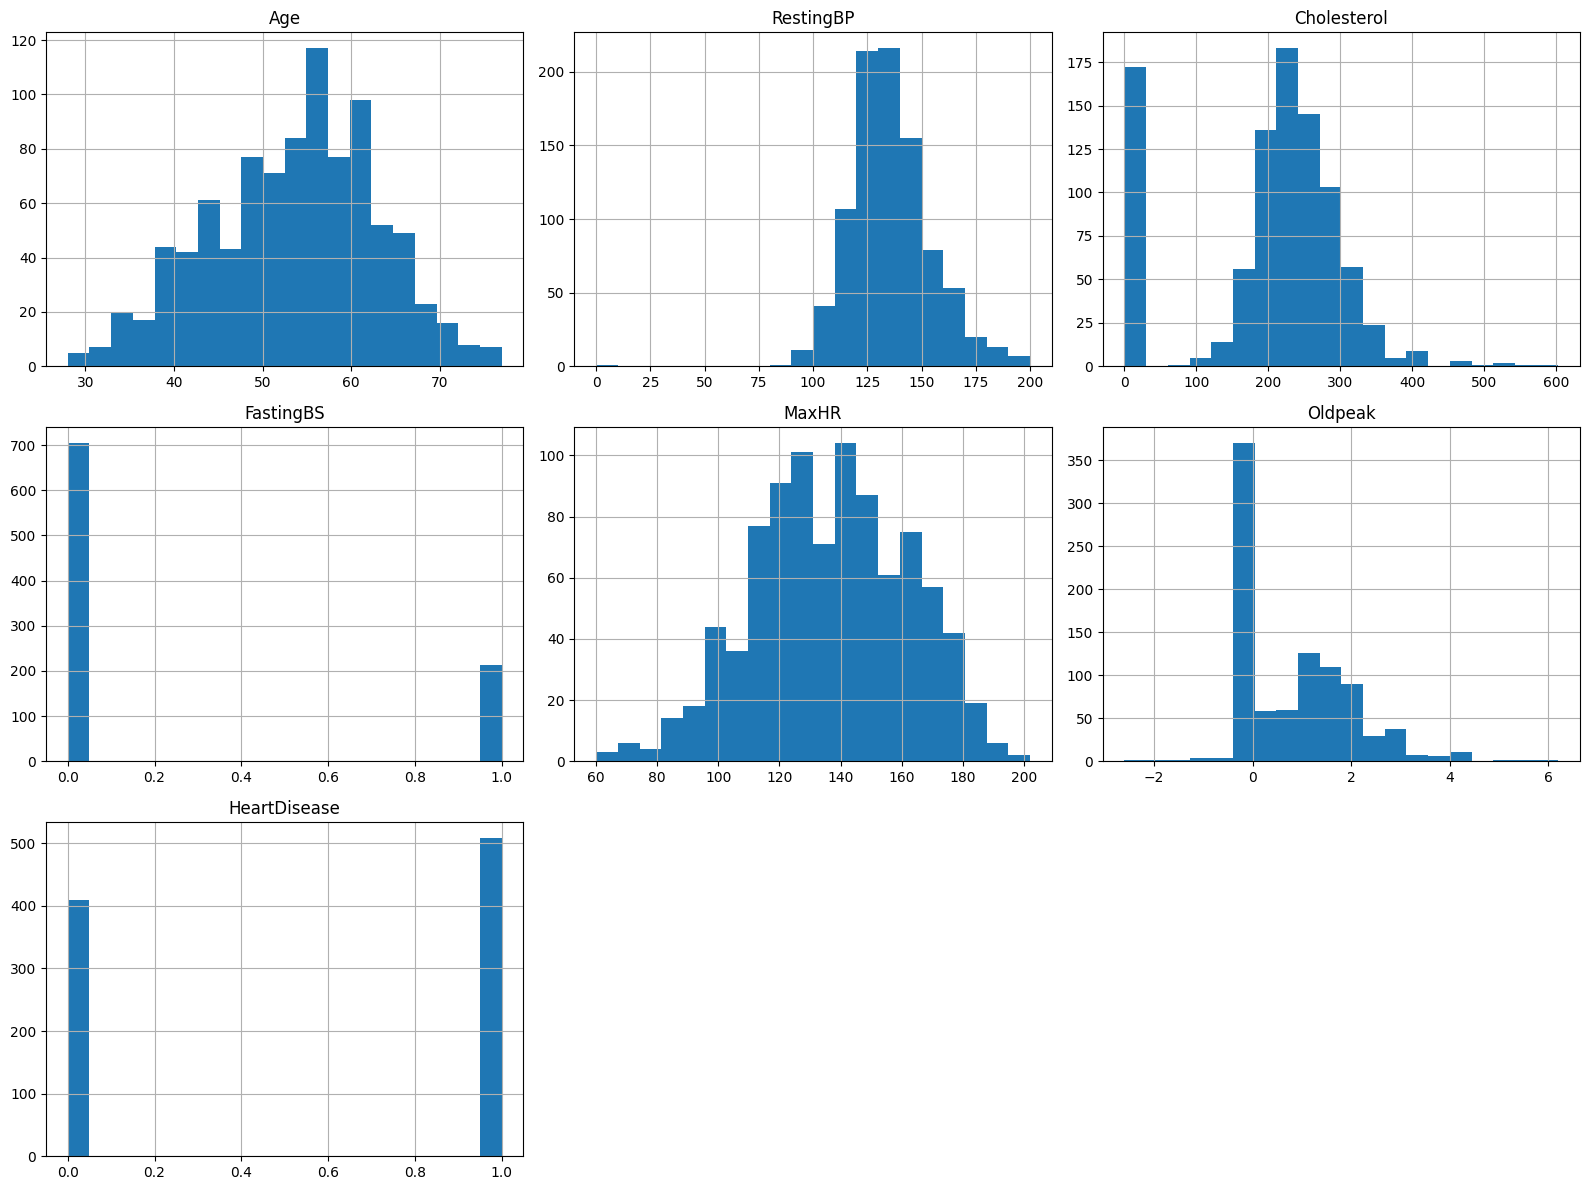

In [44]:
df.hist(figsize=(16,12), bins=20)

plt.tight_layout()
plt.show()

In [45]:
a=df["MaxHR"].mean()
print(a)

136.80936819172112


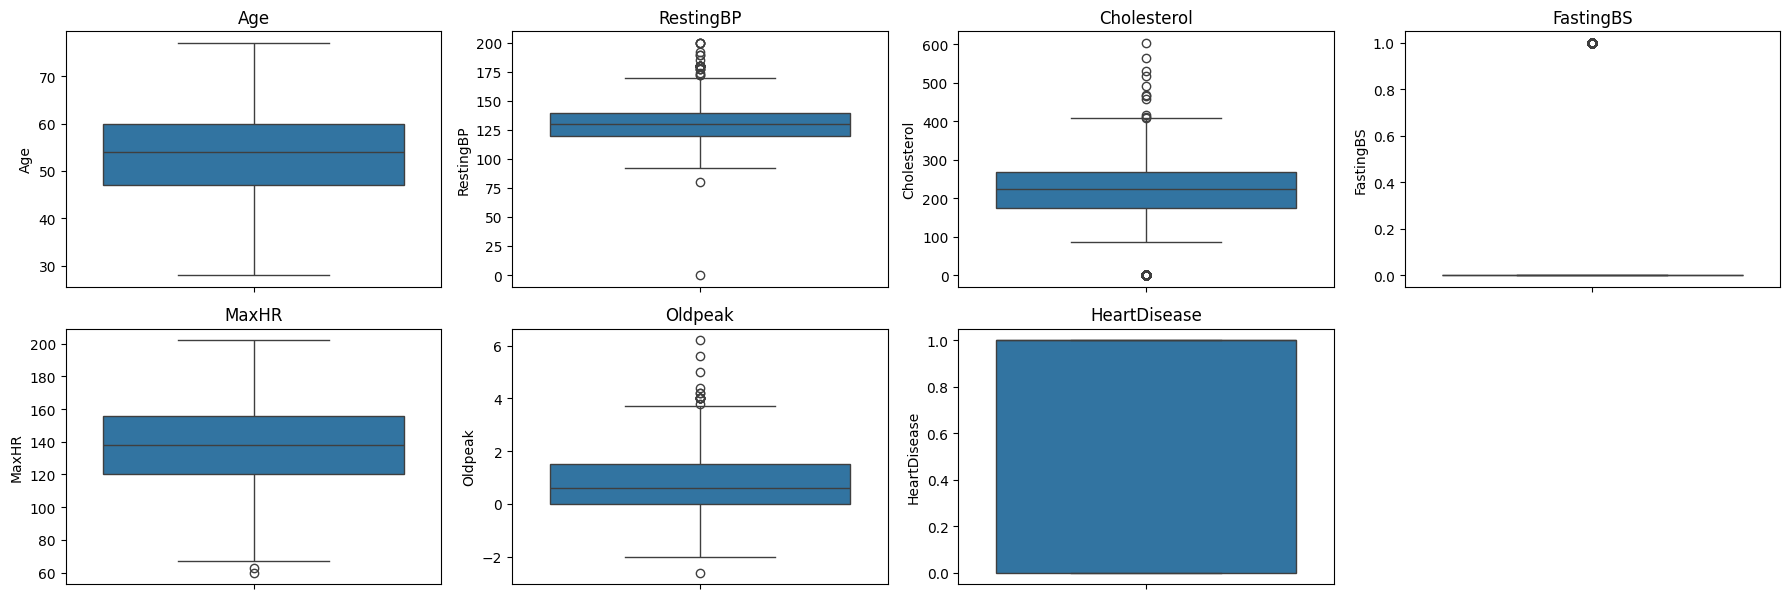

In [46]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()

plt.show()

In [47]:
print(df.dtypes)

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [48]:
categorical_cols = df.select_dtypes(include="object").columns

print(categorical_cols)

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


# **One-Hot Encoding**

In [49]:
df = pd.get_dummies(df, drop_first=True)

In [50]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [52]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (734, 15)
X_test : (184, 15)
y_train: (734,)
y_test : (184,)


In [56]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=10000,
    random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10000, random_state=42)

In [57]:
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10000, random_state=42)

In [58]:
y_pred=model.predict(X_test)

# ***The evaluation metrics***

In [59]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.2%}")
print(f"Precision : {precision:.2%}")
print(f"Recall : {recall:.2%}")
print(f"F1 Score : {f1:.2%}")

Accuracy : 86.41%
Precision : 88.68%
Recall : 87.85%
F1 Score : 88.26%
